In [147]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pickle
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
# Download latest version
path = kagglehub.dataset_download("laveshjadon/ai-impact-on-students")

print("Path to dataset files:", path)

Path to dataset files: /Users/joaofranciscoviana/.cache/kagglehub/datasets/laveshjadon/ai-impact-on-students/versions/1


**Regression** 	Post_Semester_GPA

**Classification** 	Burnout_Risk_Level

In [148]:
df = pd.read_csv(path + "/" + os.listdir(path)[0])

In [149]:
df.columns

Index(['Student_ID', 'Major_Category', 'Year_of_Study', 'Pre_Semester_GPA',
       'Weekly_GenAI_Hours', 'Primary_Use_Case', 'Prompt_Engineering_Skill',
       'Tool_Diversity', 'Paid_Subscription', 'Traditional_Study_Hours',
       'Perceived_AI_Dependency', 'Institutional_Policy',
       'Anxiety_Level_During_Exams', 'Post_Semester_GPA',
       'Skill_Retention_Score', 'Burnout_Risk_Level'],
      dtype='str')

In [150]:
df

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,149996,Business,Senior,2.899,12.16,Copywriting/Drafting,Beginner,2,False,13.36,2,Allowed_With_Citation,2,3.584,66.16,High
49996,149997,STEM,Senior,2.870,2.51,Copywriting/Drafting,Intermediate,1,False,4.67,3,Actively_Encouraged,3,3.096,81.62,Medium
49997,149998,Business,Senior,3.177,15.87,Summarizing_Reading,Advanced,5,True,3.92,4,Allowed_With_Citation,5,3.605,97.21,High
49998,149999,Business,Junior,3.398,19.91,Debugging/Troubleshooting,Intermediate,5,False,7.10,5,Allowed_With_Citation,3,3.527,84.12,Medium


# Data processing

The `Student_ID` is irrelavant for all predictions so it was dropped.

In [151]:
df.drop("Student_ID", axis=1, inplace=True)

Next `Paid_Subscription` was converted into a `0` or `1` so that it can be used in regression/classification.

In [152]:
df["Paid_Subscription"] = df["Paid_Subscription"].map(lambda x: 1. if (x) else 0.)

The `Year_of_Study` can be one of 5 possibilities, so we converted each into its own column (like OneHotEncodding)

In [153]:
print(df["Year_of_Study"].unique())

<ArrowStringArray>
['Senior', 'Junior', 'Freshman', 'Sophomore', 'Graduate']
Length: 5, dtype: str


In [154]:
set(df["Year_of_Study"])

{'Freshman', 'Graduate', 'Junior', 'Senior', 'Sophomore'}

In [155]:
def Year_of_Study_to_int(x):
    if (x == "Freshman"):
        return 0
    elif (x == "Sophomore"):
        return 1
    elif (x == "Junior"):
        return 2
    elif (x == "Senior"):
        return 3
    elif (x == "Graduate"):
        return 4
    return x # already processed
df["Year_of_Study"] = df["Year_of_Study"].map(lambda x: Year_of_Study_to_int(x))

In [156]:
def Burnout_Risk_Level_to_int(x):
    if (x == "Low"):
        return 0
    elif (x == "Medium"):
        return 1
    elif (x == "High"):
        return 2
    return x
df["Burnout_Risk_Level"] = df["Burnout_Risk_Level"].map(lambda x: Burnout_Risk_Level_to_int(x))

In [157]:
def Prompt_Engineering_Skill_int(x):
    if (x == "Beginner"):
        return 0
    elif (x == "Intermediate"):
        return 1
    elif (x == "Advanced"):
        return 2
    return x # already processed
df["Prompt_Engineering_Skill"] = df["Prompt_Engineering_Skill"].map(lambda x: Prompt_Engineering_Skill_int(x))

In [158]:
df = pd.concat([df,pd.get_dummies(df["Major_Category"],dtype=int)],axis=1)
#df.drop("Major_Category", axis=1, inplace=True)

df = pd.concat([df,pd.get_dummies(df["Primary_Use_Case"],dtype=int)],axis=1)
#df.drop("Primary_Use_Case", axis=1, inplace=True)

df = pd.concat([df,pd.get_dummies(df["Institutional_Policy"],dtype=int)],axis=1)
#df.drop("Institutional_Policy", axis=1, inplace=True)

In [159]:
df["Diff_GPA"] = df["Post_Semester_GPA"] - df["Pre_Semester_GPA"]

In [160]:
df["Diff_GPA_Relative"] = (df["Post_Semester_GPA"] - df["Pre_Semester_GPA"])/df["Pre_Semester_GPA"]

In [161]:
df

,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,...,Copywriting/Drafting,Debugging/Troubleshooting,Direct_Answer_Generation,Ideation,Summarizing_Reading,Actively_Encouraged,Allowed_With_Citation,Strict_Ban,Diff_GPA,Diff_GPA_Relative
0,Humanities,3,2.418,23.31,Copywriting/Drafting,0,1,1.0,8.13,5,...,1,0,0,0,0,0,1,0,-0.025,-0.010339
1,Medical,2,3.821,1.12,Ideation,2,5,0.0,16.65,3,...,0,0,0,1,0,0,1,0,-0.125,-0.032714
2,Business,0,3.398,21.26,Summarizing_Reading,0,2,0.0,10.35,5,...,0,0,0,0,1,0,0,1,0.101,0.029723
3,Business,3,3.789,1.82,Copywriting/Drafting,1,4,0.0,15.23,2,...,1,0,0,0,0,0,1,0,0.211,0.055688
4,STEM,1,3.635,9.29,Debugging/Troubleshooting,2,4,0.0,12.55,4,...,0,1,0,0,0,0,1,0,0.163,0.044842
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,Business,3,2.899,12.16,Copywriting/Drafting,0,2,0.0,13.36,2,...,1,0,0,0,0,0,1,0,0.685,0.236288
49996,STEM,3,2.870,2.51,Copywriting/Drafting,1,1,0.0,4.67,3,...,1,0,0,0,0,1,0,0,0.226,0.078746
49997,Business,3,3.177,15.87,Summarizing_Reading,2,5,1.0,3.92,4,...,0,0,0,0,1,0,1,0,0.428,0.134718
49998,Business,2,3.398,19.91,Debugging/Troubleshooting,1,5,0.0,7.10,5,...,0,1,0,0,0,0,1,0,0.129,0.037964


# EDA

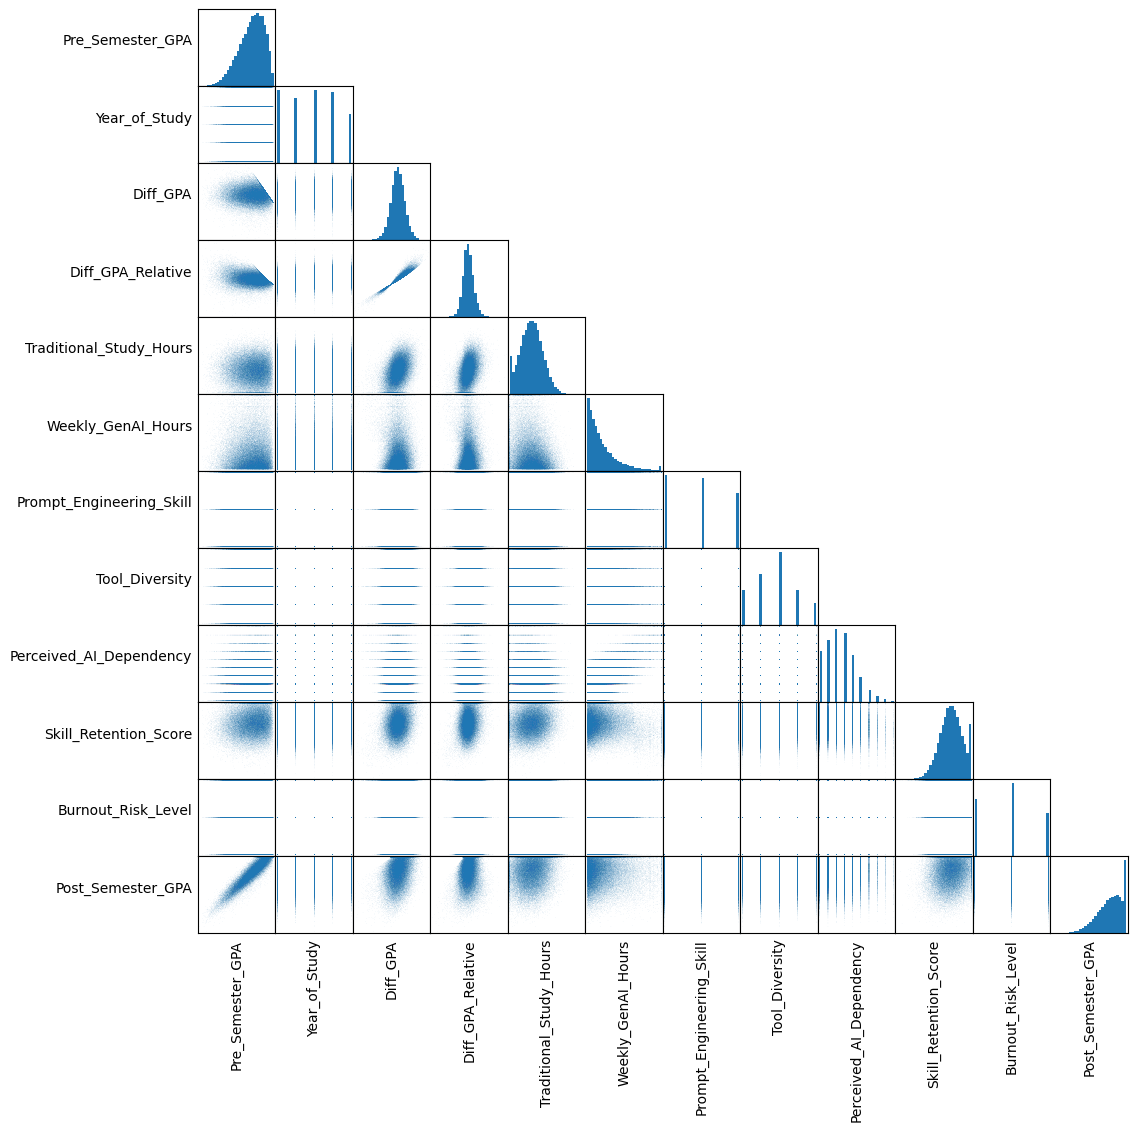

In [162]:
features = ["Pre_Semester_GPA", "Year_of_Study", "Diff_GPA", "Diff_GPA_Relative","Traditional_Study_Hours", "Weekly_GenAI_Hours", "Prompt_Engineering_Skill", "Tool_Diversity", "Perceived_AI_Dependency", "Skill_Retention_Score"]
target = ["Burnout_Risk_Level" , "Post_Semester_GPA"]

axes = pd.plotting.scatter_matrix(df[features + target], alpha=0.9, figsize=(12,12), diagonal="hist", s=0.1, hist_kwds={'bins': 30})

for i in range(np.shape(axes)[0]):
    for j in range(i + 1, np.shape(axes)[1]):
        axes[i,j].set_visible(False)

for ax in axes.flatten():
    ax.xaxis.label.set_rotation(90)
    ax.yaxis.label.set_rotation(0)
    ax.yaxis.label.set_ha('right')

    #ax.tick_params(axis=u'both', which=u'both',length=0)
    ax.set_xticks([])
    ax.set_yticks([])
    
plt.show()

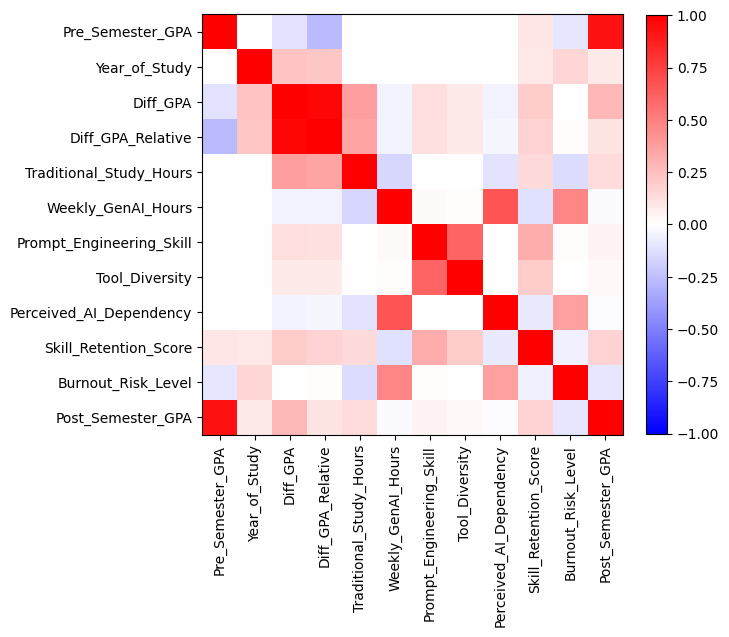

In [163]:
corr = df[features + target].corr()

# set upper triangular matrix to zero, including diagonal
#for i in range(0, corr.shape[0]):
#    for j in range(i, corr.shape[0]):
#        corr.iloc[i,j] = 0

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="bwr")

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.columns)

fig.colorbar(im, fraction=0.045)

plt.show()

# Preprocessing

Here I care only about getting a Gaussian-like distribution for the continous features, standardization is going to get handled later.

## Check `Perceived_AI_Dependency` and `Skill_Retention_Score` 

Just double checking these two but their distributions appear Gaussian-like so they should be OK for prediction.

Text(0.5, 0, 'Perceived_AI_Dependency')

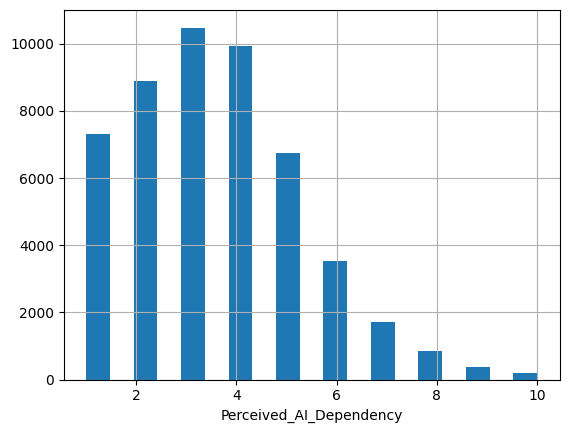

In [164]:
# I don't expect a multiplicative behaviour for this feature, so I will keep it as is.
df["Perceived_AI_Dependency"].hist(bins=19)
plt.xlabel("Perceived_AI_Dependency")

## Remove bias in data (df["Weekly_GenAI_Hours"])

Looking at an histogram of `Weekly_GenAI_Hours` we see some weird behaviour on the data. The concentration of points at $40$ hours probably comes from an upper bound set manually at $40$ hours. The origin of the other is not known except that they occur at $34$, $36$, $38$.

We moved these points points that are bang on these values.

In [165]:
import scipy.stats as st

In [166]:
nbins = 300
pvalue_treshold = 0.05

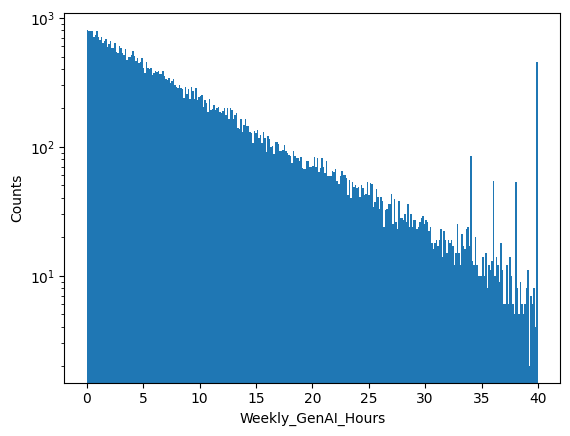

In [167]:
counts, bin_edges, patches = plt.hist(df["Weekly_GenAI_Hours"], bins=nbins)

plt.yscale("log")
plt.xlabel("Weekly_GenAI_Hours")
plt.ylabel("Counts")

plt.show()

In log scale, looks linear so we will try a exponential distribution

In [168]:
loc, scale = st.expon.fit(df["Weekly_GenAI_Hours"])

print("Loc =", loc, "\nScale =", scale)

weekly_dist = st.expon(loc=loc, scale=scale)

Loc = 0.0 
Scale = 8.4277522


In [169]:
pvalues = []

expected_counts = []

for i in range(len(bin_edges) - 1):
    lower = bin_edges[i]
    upper = bin_edges[i + 1]

    p = weekly_dist.cdf(upper) - weekly_dist.cdf(lower)

    N = len(df["Weekly_GenAI_Hours"])

    res = st.binomtest(int(counts[i]), N, p, alternative='greater')

    pvalues.append(res.pvalue)

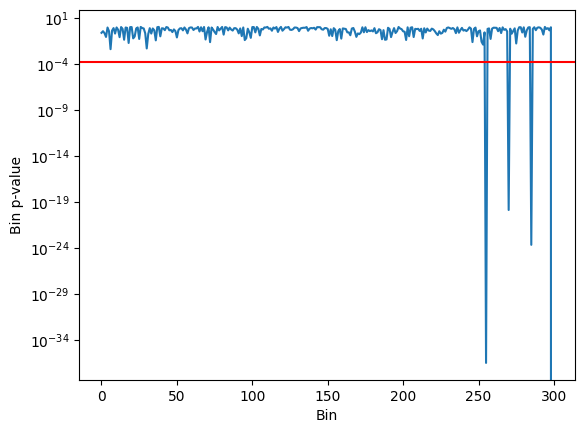

In [170]:
plt.plot(pvalues)

plt.axhline(pvalue_treshold/nbins, c="r") # look elsewhere effect

plt.xlabel("Bin")

plt.ylabel("Bin p-value")

plt.yscale("log")

In [171]:
for i in range(len(bin_edges) - 1):
    
    lower = bin_edges[i]
    upper = bin_edges[i + 1]
    
    if pvalues[i] < pvalue_treshold/nbins:
        print("Bin edged ->", lower, "->", upper)
        
        values = df["Weekly_GenAI_Hours"][(df["Weekly_GenAI_Hours"] >= lower) & (df["Weekly_GenAI_Hours"] <= upper)]
        print(values.value_counts(), "\n\n")
        

Bin edged -> 34.0 -> 34.13333333333333
Weekly_GenAI_Hours
34.00    66
34.11     3
34.03     2
34.13     2
34.05     2
34.01     2
34.08     2
34.09     1
34.06     1
34.02     1
34.10     1
34.07     1
Name: count, dtype: int64 


Bin edged -> 36.0 -> 36.13333333333333
Weekly_GenAI_Hours
36.00    41
36.12     3
36.02     2
36.08     2
36.06     2
36.03     1
36.10     1
36.04     1
36.11     1
Name: count, dtype: int64 


Bin edged -> 38.0 -> 38.13333333333333
Weekly_GenAI_Hours
38.00    48
38.13     1
38.09     1
38.08     1
38.10     1
38.06     1
Name: count, dtype: int64 


Bin edged -> 39.86666666666667 -> 40.0
Weekly_GenAI_Hours
40.00    448
39.91      1
39.90      1
39.99      1
39.97      1
Name: count, dtype: int64 




In [172]:
unbiased_points = (df["Weekly_GenAI_Hours"] != 34.0) & (df["Weekly_GenAI_Hours"] != 36.0) & (df["Weekly_GenAI_Hours"] != 38.0)& (df["Weekly_GenAI_Hours"] != 40.0)

print("Removing", df.shape[0] - df[unbiased_points].shape[0], "points")

df = df[unbiased_points]

Removing 603 points


Text(0.5, 0, 'Weekly_GenAI_Hours')

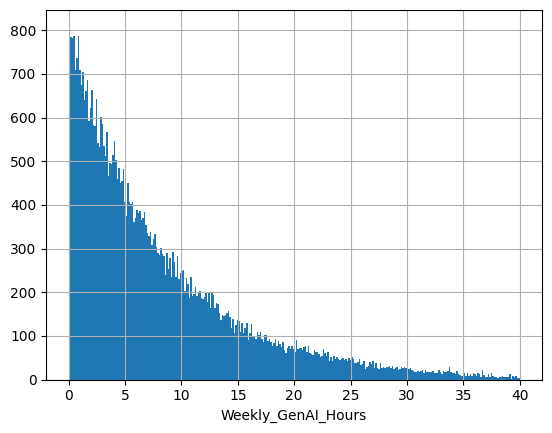

In [173]:
df["Weekly_GenAI_Hours"].hist(bins=300)

plt.xlabel("Weekly_GenAI_Hours")

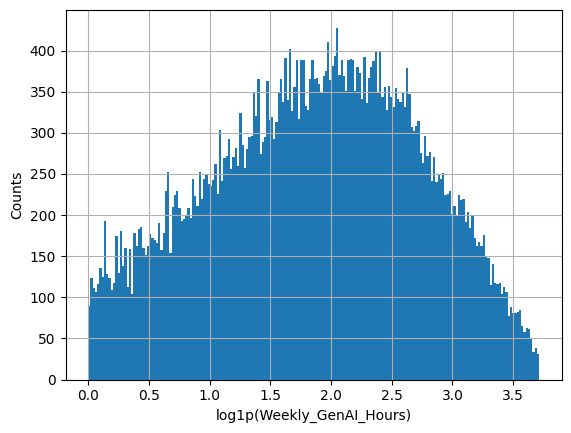

In [175]:
temp_data = df["Weekly_GenAI_Hours"]

#temp_data = np.log1p(temp_data)
temp_data.hist(bins=200)
plt.ylim()
plt.xlabel("log1p(Weekly_GenAI_Hours)")
plt.ylabel("Counts")

df["Weekly_GenAI_Hours"] = temp_data

## Remove bias "Traditional_Study_Hours"

Text(0, 0.5, 'Counts')

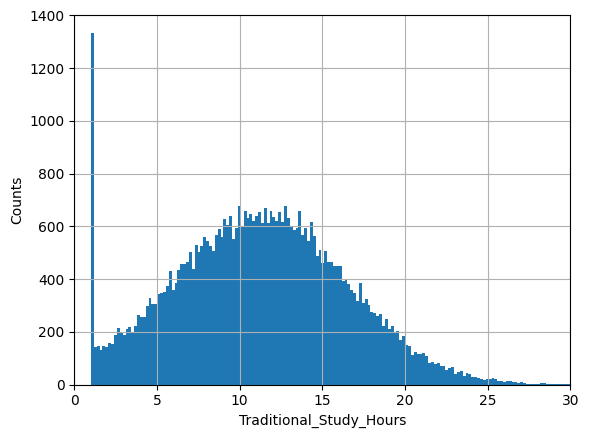

In [193]:
df["Traditional_Study_Hours"].hist(bins=200)
plt.xlim([0,30])
plt.xlabel("Traditional_Study_Hours")
plt.ylabel("Counts")

In [194]:
df["Traditional_Study_Hours"][df["Traditional_Study_Hours"] < 30].value_counts()[:10]

Traditional_Study_Hours
1.00     1223
9.88       54
9.47       54
10.99      52
12.76      51
12.38      51
12.02      51
12.94      51
12.10      50
13.58      49
Name: count, dtype: int64

In [195]:
unbiased_points = (df["Traditional_Study_Hours"] != 1.0)

print("Removing", df.shape[0] - df[unbiased_points].shape[0], "points")

df = df[unbiased_points]

Removing 1223 points


Text(0.5, 0, 'Traditional_Study_Hours')

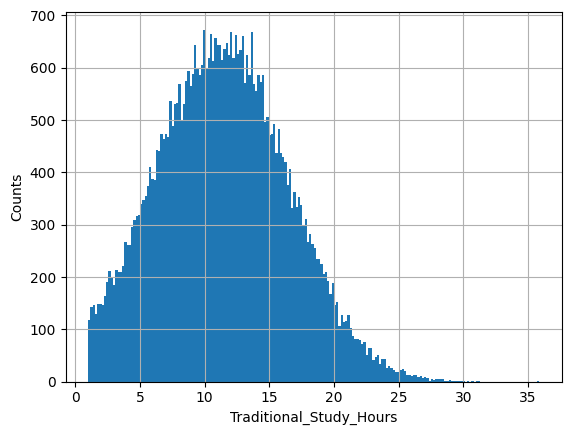

In [196]:
df["Traditional_Study_Hours"].hist(bins=200)
plt.ylabel("Counts")
plt.xlabel("Traditional_Study_Hours")

## Remove bias on "Skill_Retention_Score"

Text(0.5, 0, 'Skill_Retention_Score')

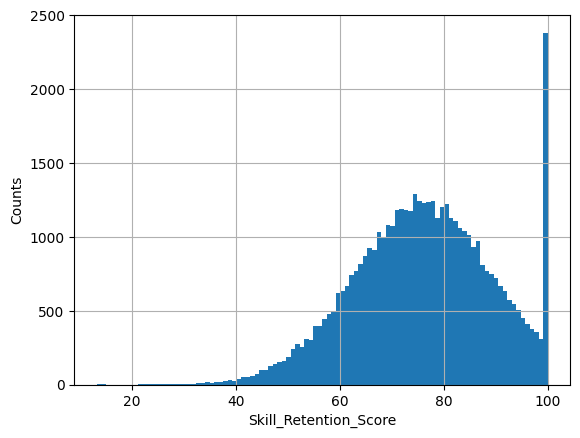

In [197]:
df["Skill_Retention_Score"].hist(bins=100)
plt.ylabel("Counts")
plt.xlabel("Skill_Retention_Score")

In [198]:
df["Skill_Retention_Score"].value_counts()[:10]

Skill_Retention_Score
100.00    2116
74.77       27
76.46       26
87.34       25
77.06       25
75.44       25
81.58       25
81.96       24
79.87       24
72.94       24
Name: count, dtype: int64

In [199]:
unbiased_points = (df["Skill_Retention_Score"] != 100.00)

print("Removing", df.shape[0] - df[unbiased_points].shape[0], "points")

df = df[unbiased_points]

Removing 2116 points


## EPA on Post_Semester_GPA

A correlation matrix is also very helpful. We can those same correlations here.

In [396]:
df["Post_Semester_GPA"].mean()

np.float64(3.344851795562117)

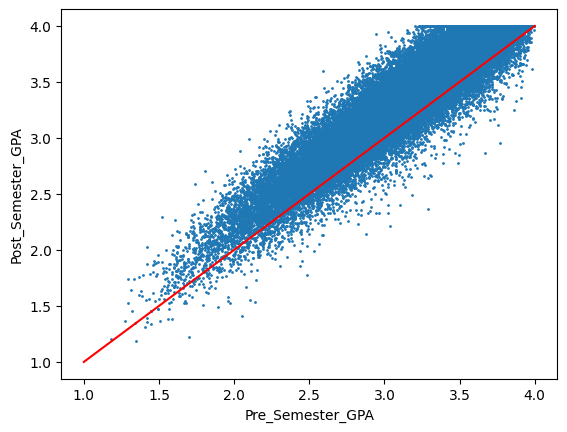

In [200]:
sc = plt.scatter(df["Pre_Semester_GPA"], df["Post_Semester_GPA"],s=1)

plt.plot([1,4],[1,4], c="r")
plt.xlabel("Pre_Semester_GPA")
plt.ylabel("Post_Semester_GPA")
plt.show()

After making a scatter plot of the GPA before and after the use of GenAI and plot the $y=x$ line we can see that, overall, grades increased after the use of AI. We can also see a linear relation with some variation.

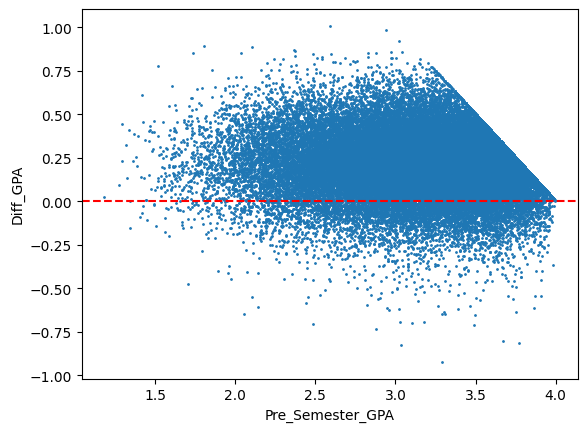

In [201]:
sc = plt.scatter(df["Pre_Semester_GPA"], df["Diff_GPA"], s=1)
plt.xlabel("Pre_Semester_GPA")
plt.ylabel("Diff_GPA")
plt.axhline(y=0, c="r", linestyle="--")
plt.show()

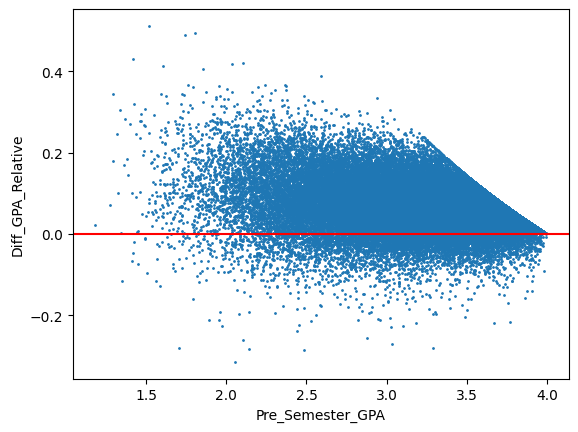

In [202]:
sc = plt.scatter(df["Pre_Semester_GPA"], df["Diff_GPA_Relative"], s=1)
plt.xlabel("Pre_Semester_GPA")
plt.ylabel("Diff_GPA_Relative")
plt.axhline(y=0, c="r", linestyle="-")
plt.show()

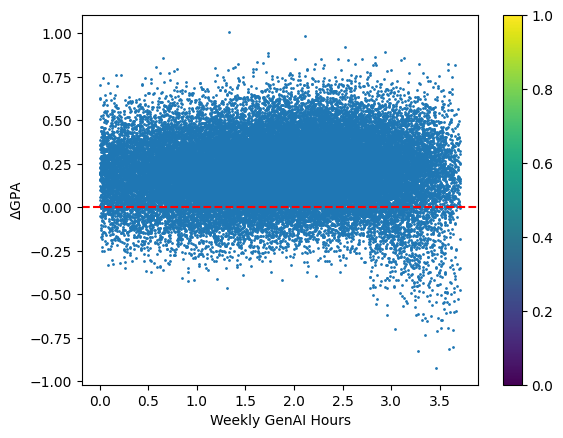

In [203]:
sc = plt.scatter(df["Weekly_GenAI_Hours"], df["Diff_GPA"], s=1)
plt.colorbar(sc)
plt.xlabel("Weekly GenAI Hours")
plt.ylabel(r"$\Delta$GPA")
plt.axhline(y=0, c="r", linestyle="--")
plt.show()

This plot is very interesting. On the x-axis we show the weekly GenAI hours and on the y-axis we show the difference in GPA. We can see that most points are above the $y=0$ line, independently of the number of hours GenAI usage. This indicates that the increase in GPA does not come from the use of GenAI, but instead comes from an external factor that happens to correlated with the use of GenAI.

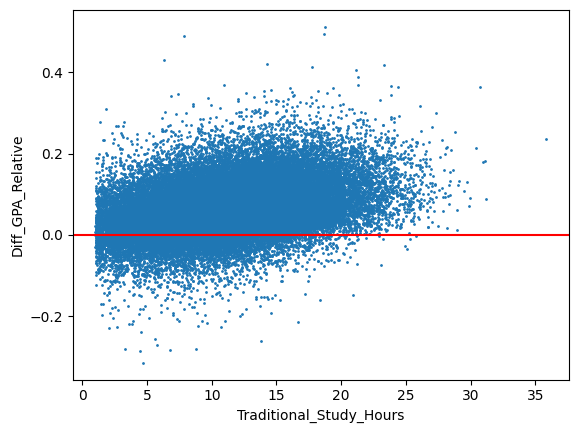

In [207]:
sc = plt.scatter(df["Traditional_Study_Hours"], df["Diff_GPA_Relative"], s=1)
plt.xlabel("Traditional_Study_Hours")
plt.ylabel("Diff_GPA_Relative")
plt.axhline(y=0, c="r", linestyle="-")
plt.show()

In plotting the traditional study hours versus the difference in GPA ($\Delta$ GPA) it is also easy to see the positive correlation between the two.

## EDA on `Burnout_Risk_Level`

In [42]:
df["Burnout_Risk_Level"].value_counts()

Burnout_Risk_Level
1    19682
0    15391
2    10985
Name: count, dtype: int64

Text(0, 0.5, 'Diff_GPA_Relative')

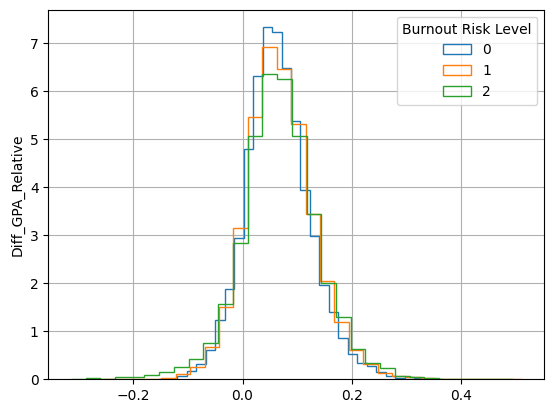

In [43]:
ax = df.groupby("Burnout_Risk_Level")["Diff_GPA_Relative"].hist(density=True,
                                                           histtype=u'step',
                                                           bins=30, 
                                                           legend=True,
                                                           linewidth=1)[0]
ax.legend(title="Burnout Risk Level")
ax.set_ylabel("Diff_GPA_Relative")

# Regression (`Post_Semester_GPA`)

In [57]:
from tqdm import tqdm
from sklearn.model_selection import KFold, ParameterGrid
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_percentage_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE, RFECV
from xgboost import XGBRegressor

The goal of this section is predict the `Post_Semester_GPA` as accuratly as I can using the metric `RMSE`, i.e. i want to be close to the true value in absolute distance.

Looking at the `Pre_Semester_GPA` vs. `Post_Semester_GPA`, I suspect right away that a linear model should perform quite decently. Neverthess, I will fit a series of regression models, use a K-fold to estimate the sampling variance, and finally calculate model performance. We will test the following models

 - Linear Model
 - Support vector regression
 - KNN
 - Random Forests
 - Boosted Decisition Trees

In order to select the features to train the model, I used recursive feature elimination (RFE) to select the 10 most relevant ones for a `max_depth=2` for a boosted decisiton tree. I selected boosted decisiton tree because, from trial and error, saw that SVR seem to produce the best results so, to not be biased, selected another model architecture.

## Feature selection

### RFECV

In [45]:
target = ["Post_Semester_GPA"]
dropped_features = target + ["Humanities", "Major_Category", "Primary_Use_Case", "Institutional_Policy", "Diff_GPA", "Diff_GPA_Relative", "Post_Semester_GPA", "Burnout_Risk_Level"]

X_FS = df.drop(dropped_features, axis=1).to_numpy()
y_FS = df[target].to_numpy()

scaler = StandardScaler()
X_FS_scaled = scaler.fit_transform(X_FS)

In [52]:
estimator = XGBRegressor(max_depth=6, random_state=42, n_jobs=-1)

selector = RFECV(estimator, step=1, cv=5)
selector = selector.fit(X_FS_scaled, y_FS.ravel())

features_boosted = list(df.drop(dropped_features, axis=1).columns[selector.support_])

print("Features are = ", features_boosted)

Features are =  ['Year_of_Study', 'Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Prompt_Engineering_Skill', 'Paid_Subscription', 'Traditional_Study_Hours', 'Debugging/Troubleshooting', 'Direct_Answer_Generation', 'Strict_Ban']


In [48]:
estimator = RandomForestRegressor(max_depth=6, random_state=42, n_jobs=-1)

selector = RFECV(estimator, step=1, cv=5)
selector = selector.fit(X_FS_scaled, y_FS.ravel())

features_randomforest = list(df.drop(dropped_features, axis=1).columns[selector.support_])

print("Features are = ", features_randomforest)

Features are =  ['Year_of_Study', 'Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Prompt_Engineering_Skill', 'Traditional_Study_Hours', 'Skill_Retention_Score', 'Debugging/Troubleshooting', 'Direct_Answer_Generation']


### Tree-Based Feature Importance

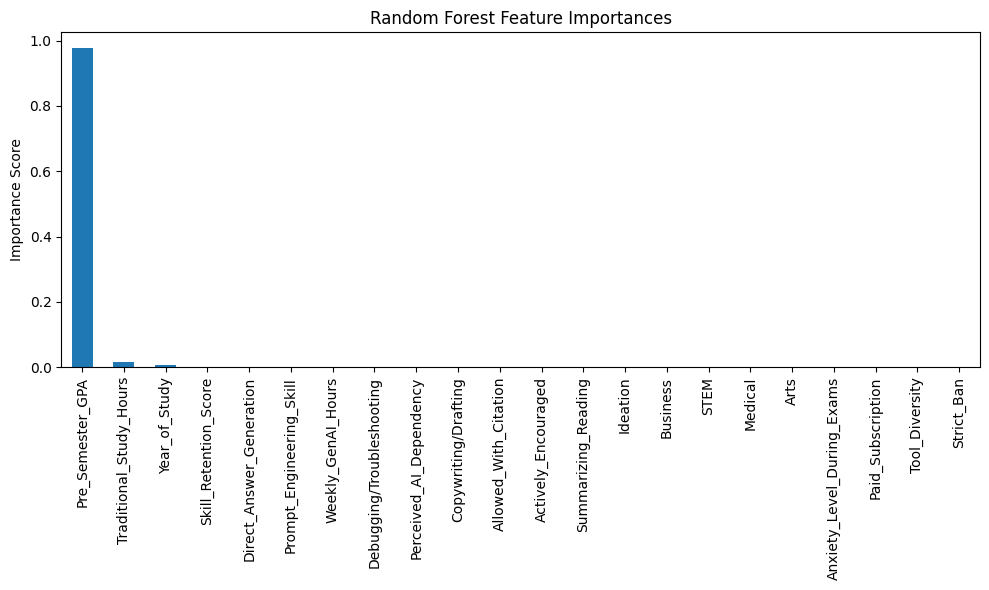

In [49]:
rf = RandomForestRegressor(n_estimators=100, max_depth=6, random_state=42)
rf.fit(X_FS_scaled, y_FS.ravel())

importances = pd.Series(rf.feature_importances_, index=df.drop(dropped_features, axis=1).columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))

# Select features above a threshold
threshold = 0  # Usually determined by inspection or cross-validation
selected_features = importances[importances >= threshold].index.tolist()

importances[importances >= threshold].plot(kind='bar')

plt.title('Random Forest Feature Importances')
plt.ylabel('Importance Score')

plt.tight_layout()

In [50]:
## Keep 0.99 of the information
features_randomforest_importance = importances[:len(importances[importances.cumsum() < 0.99]) + 1].index.to_list()
features_randomforest_importance

['Pre_Semester_GPA', 'Traditional_Study_Hours']

In [53]:
features_series = pd.Series(features_boosted + features_randomforest + features_randomforest_importance).value_counts()
features = features_series[features_series > 1].index.to_list()
features

['Pre_Semester_GPA',
 'Traditional_Study_Hours',
 'Year_of_Study',
 'Weekly_GenAI_Hours',
 'Prompt_Engineering_Skill',
 'Debugging/Troubleshooting',
 'Direct_Answer_Generation']

On the following code block, we do 5-fold cross validation, in order to remove sampling bias, and train each model architecture.

In [416]:
#models = []
labels = []

####### Linear

models.append(LinearRegression())
labels.append("Linear")

####### KNN

param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 21, 23, 30, 35, 40],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

for params in ParameterGrid(param_grid):
    neigh = KNeighborsRegressor(**params)
    models.append(neigh)
    labels.append("KNN_" + "_".join(f"{v}" for k, v in params.items()))

####### Random Forest

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, 20],
    'min_samples_split': [2, 10],
    'min_samples_leaf': [1, 4],
    'max_features': ['sqrt', 'log2']}

for params in ParameterGrid(param_grid):
    rf = RandomForestRegressor(random_state=42, n_jobs=1, **params)
    models.append(rf)
    labels.append("RandomForest_" + "_".join(f"{v}" for k, v in params.items()))

###### BoostedDecisionTrees

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, 10, 20],
    'learning_rate': [0.05, 0.1]
}

for params in ParameterGrid(param_grid):
    boosted = XGBRegressor(random_state=42, n_jobs=1, **params)
    models.append(boosted)
    labels.append("BoostedTree_" + "_".join(f"{v}" for k, v in params.items()))


####### SVR 

param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto', 0.1, 1]
}

for params in ParameterGrid(param_grid):
    svr = SVR(**params)
    models.append(svr)  
    labels.append("SVR" + "_".join(f"{v}" for k, v in params.items()))

In [59]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

metric = root_mean_squared_error

regre_reports = np.empty((len(models), kf.get_n_splits(),2), dtype=object)

#for i, (train_index, test_index) in enumerate(tqdm(kf.split(df[features]),total=len(list(kf.split(df[features]))))):

for i, (train_index, test_index) in enumerate(kf.split(df[features])):
    X_train = df[features].iloc[train_index].to_numpy()
    y_train = df[target].iloc[train_index].to_numpy()

    X_test = df[features].iloc[test_index].to_numpy()
    y_test = df[target].iloc[test_index].to_numpy()
    
    scaler = StandardScaler()
    scaler.fit(X_train)

    X_train_scaled = scaler.transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    ##### Train

    for m in tqdm(range(len(models)), desc="K " + str(1 + i)):
        models[m].fit(X_train_scaled, y_train.ravel())
        y_pred = models[m].predict(X_test_scaled)
        regre_reports[m][i][0] = root_mean_squared_error(y_test, y_pred)
        regre_reports[m][i][1] = mean_absolute_percentage_error(y_test, y_pred)

np.save("regression_reports", regre_reports, allow_pickle=True)

K 5: 100%|████████████████████████████████████████████████████████████████████████████████████████| 155/155 [42:06<00:00, 16.30s/it]


In [418]:
regre_reports = np.load("regression_reports.npy", allow_pickle=True)

In [59]:

## OLDLLDD
features = list(df.drop(dropped_features, axis=1).columns[selector.support_]) 
target = ["Post_Semester_GPA"]

kf = KFold(n_splits=5, shuffle=True, random_state=42)

metric_RMSE = root_mean_squared_error
metric_MAPE = mean_absolute_percentage_error

scores_RMSE = []
scores_MAPE = []

for i, (train_index, test_index) in enumerate(tqdm(kf.split(df[features]),total=len(list(kf.split(df[features]))))):
    score_RMSE = []
    score_MAPE = []
    labels = []
    
    X_train = df[features].iloc[train_index]
    y_train = df[target].iloc[train_index]

    X_test = df[features].iloc[test_index]
    y_test = df[target].iloc[test_index]

    #Scaler (for KNN and SVR)
    scaler = StandardScaler()
    scaler.fit(X_train)

    X_train_scaled = scaler.transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    ####### Linear regression

    reg = LinearRegression().fit(X_train, y_train)
    score_RMSE.append(metric_RMSE(y_test, reg.predict(X_test)))
    score_MAPE.append(metric_MAPE(y_test, reg.predict(X_test)))
    labels.append("Linear")

    ####### SVR 

    svr = SVR()
    svr.fit(X_train_scaled, y_train.values.ravel())
    score_RMSE.append(metric_RMSE(svr.predict(X_test_scaled), y_test.values.ravel()))
    score_MAPE.append(metric_MAPE(y_test.values.ravel(), svr.predict(X_test_scaled)))
    labels.append("SVR")

    ###### KNN regression
    
    for n in range(2,50,4):
        neigh = KNeighborsRegressor(n_neighbors=n)
        neigh.fit(X_train_scaled, y_train)
        score_RMSE.append(metric_RMSE(neigh.predict(X_test_scaled), y_test))
        score_MAPE.append(metric_MAPE(y_test, neigh.predict(X_test_scaled)))
        labels.append("KNN_" + str(n))

    ###### Random Forest Regression
    
    for n in range(2,16,2):
        randomforest = RandomForestRegressor(max_depth=n, random_state=42)
        randomforest.fit(X_train, y_train.values.ravel())
        score_RMSE.append(metric_RMSE(randomforest.predict(X_test), y_test))
        score_MAPE.append(metric_MAPE(y_test, randomforest.predict(X_test)))
        labels.append("RandomForest_" + str(n))

    ###### BoostedDecisionTrees
    
    for n in range(2,16,2):
        boosted = XGBRegressor(max_depth=n,random_state=42)
        boosted.fit(X_train, y_train)
        score_RMSE.append(metric_RMSE(boosted.predict(X_test), y_test))
        score_MAPE.append(metric_MAPE(y_test, boosted.predict(X_test)))
        labels.append("BoostedTree_" + str(n))

    ######

    scores_RMSE.append(score_RMSE)
    scores_MAPE.append(score_MAPE)

scores_RMSE = np.array(scores_RMSE)
scores_MAPE = np.array(scores_MAPE)
labels = np.array(labels)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [08:17<00:00, 99.59s/it]


## RMSE

In the following plot, I show the $\text{RMSE} = \frac{1}{n}\sum_i \sqrt{(y_i-y_\text{prec})^2}$ results for all models.

In [215]:
regression_reports = np.load("regression_reports.npy", allow_pickle=True)


In [220]:
regression_reports.shape

(155, 5, 2)

In [222]:
len(labels)

155

In [224]:
regression_reports[:,:,0].shape

(155, 5)

In [421]:
scores_RMSE = regression_reports[:,:,0].T
scores_MAPE = regression_reports[:,:,1].T
labels = np.array(labels)

In the following plot I splot only the 11 best models, according to the RMSE metric.

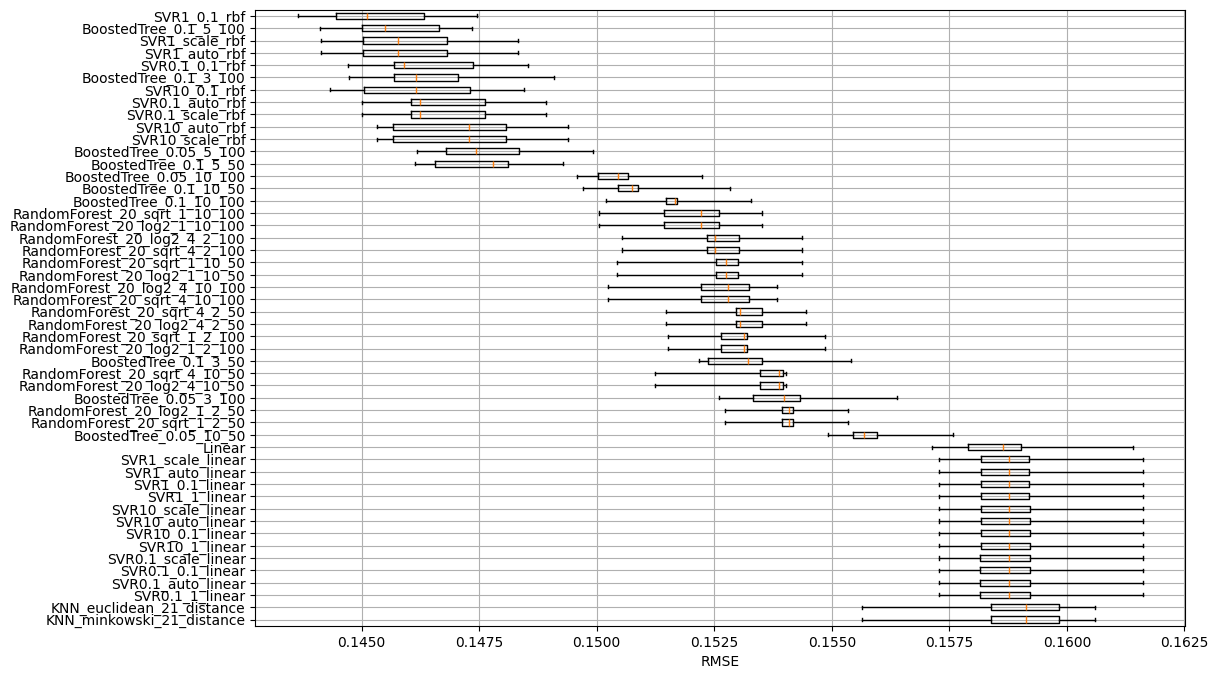

In [426]:
N_best = 50
index_best = np.argsort(np.median(scores_RMSE,axis=0))[:N_best]

fig, ax = plt.subplots(figsize=(12,8))
VP = ax.boxplot((scores_RMSE[:,index_best]), orientation='horizontal', tick_labels=labels[index_best], whis=10)

ax.invert_yaxis()
ax.set_xlabel("RMSE")
plt.grid()

We can see that SVR is the best performer, followed by boosted trees and random forests. The linear model perfoms slightly worse but, due to its simplificty and explainability, can still be used in some scenarios. KNN seems to be the worse performers, with a RMSR around 10%-20% higher than SVMs.

## MAPE

I also show the results using instead the MAPE metric which is given by $\text{MAPE} = \frac{1}{n}\sum_i\frac{|y_i-y_\text{pred}|}{\max(\epsilon, |y_i|)}$. This metric tells us the average relative error of each regression model.

In the following plot I splot only the 11 best models, according to the MAPE metric.

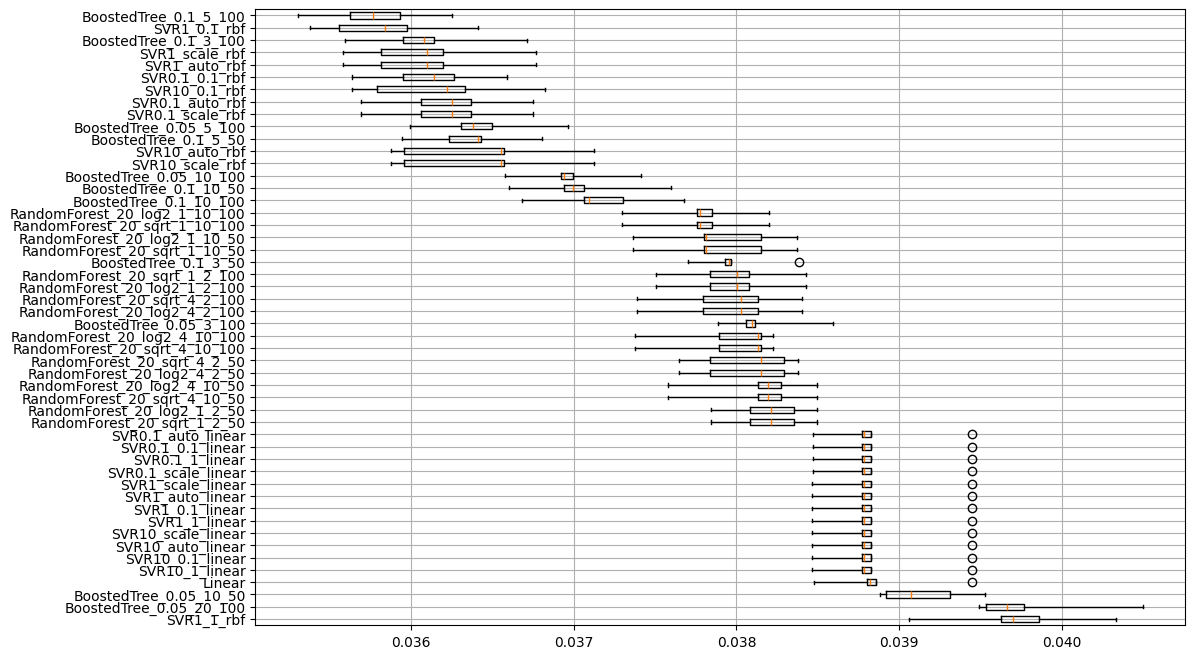

In [425]:
N_best = 50

index_best = np.argsort(np.median(scores_MAPE,axis=0))[: N_best]

fig, ax = plt.subplots(figsize=(12,8))
VP = ax.boxplot((scores_MAPE[:,index_best]), orientation='horizontal', tick_labels=labels[index_best], whis=10)

ax.invert_yaxis()

plt.grid()

For MAPE, the best model is Boosted Decision Trees with depth = 4, followed by SVR, and then by boosted trees and random forests.

Random forest with depth = 2 seems to have the largest error, with the median being 5.6% error while the best model has 3.6% median error.

The linear model still performs pretty well using the MAPE metric, with a median error of 3.91%.

## What is the best model?

From our plots it seems that the best model depends on the metric, and that is true. To chose the best model, one has to decide what one really wants. If one wants:

- Small errors in absolute value $\to$ choose the best RMSE
- Small errors in relative value $\to$ choose the best MAPE

These are not the same, if one has a target variable that spans several orders of magnitude the RMSE will be misleading as the model will try to fit the largest values. For the `Post_Semester_GPA`, we have that $0 <$ `Post_Semester_GPA` $< 4$ so its likely not big deal. Anyway, `BoostedTree_4` and `SVR` are very close in both metrics, and both within the "error bars" of each model accurary, so there is no need to be concerned in this case.

# Classification (`Burnout_Risk_Level`)

In [234]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
from sklearn import svm
from sklearn.model_selection import KFold, ParameterGrid
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.feature_selection import RFE, RFECV

My goal here is to predict the `Burnout_Risk_Level` as `Low`, `Medium`, `High` best as I can while simultaneously predicting atleast $90%$ of the `High` class as true positives, so that they can get proper treatment.

I will run classifier to classify all three classes. And then do threshold tunning to improve the accuracy on the `High` class.


## Feature selection

In [235]:
target = ["Burnout_Risk_Level"]
dropped_features = target + ["Humanities", "Major_Category", "Primary_Use_Case", "Institutional_Policy", "Diff_GPA", "Diff_GPA_Relative", "Post_Semester_GPA"]

X_FS = df.drop(dropped_features, axis=1).to_numpy()
y_FS = df[target].to_numpy()

scaler = StandardScaler()
X_FS_scaled = scaler.fit_transform(X_FS)

### RFECV

In this section, we are going to try to predict the `Burnout_Risk_Level` of the students based on the available features.

To know which features to use, we used an RFE algorithm to select the most predictive features when fitted to a `RandomForesClassifier` with `max_depth=6`. From testing some architecture and features, we figured that this architecture produced decent results without being the best performer

In [236]:
estimator = XGBClassifier(max_depth=6, random_state=42, n_jobs=-1)

selector = RFECV(estimator, step=1, cv=5)
selector = selector.fit(X_FS_scaled, y_FS)

features_boosted = list(df.drop(dropped_features, axis=1).columns[selector.support_])

print("Features are = ", features_boosted)

Features are =  ['Year_of_Study', 'Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Traditional_Study_Hours', 'Perceived_AI_Dependency', 'Direct_Answer_Generation', 'Strict_Ban']


In [237]:
estimator = RandomForestClassifier(max_depth=6, random_state=42, n_jobs=-1)

selector = RFECV(estimator, step=1, cv=5)
selector = selector.fit(X_FS_scaled, y_FS.ravel())

features_randomforest = list(df.drop(dropped_features, axis=1).columns[selector.support_])

print("Features are = ", features_boosted)

Features are =  ['Year_of_Study', 'Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Traditional_Study_Hours', 'Perceived_AI_Dependency', 'Direct_Answer_Generation', 'Strict_Ban']


### Tree-Based Feature Importance

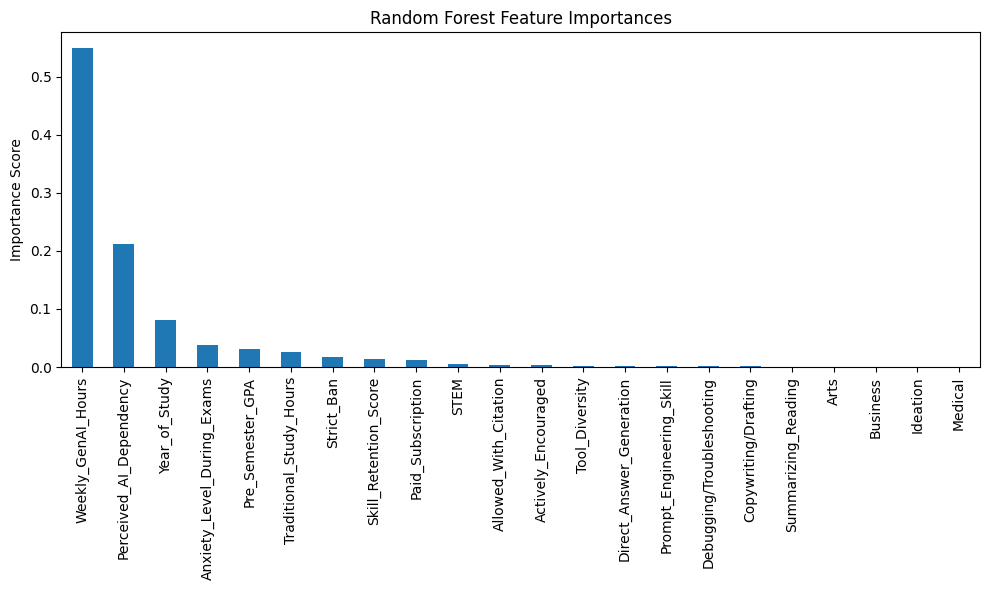

In [238]:
rf = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
rf.fit(X_FS_scaled, y_FS.ravel())

importances = pd.Series(rf.feature_importances_, index=df.drop(dropped_features, axis=1).columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))

# Select features above a threshold
threshold = 0  # Usually determined by inspection or cross-validation
selected_features = importances[importances >= threshold].index.tolist()

importances[importances >= threshold].plot(kind='bar')

plt.title('Random Forest Feature Importances')
plt.ylabel('Importance Score')

plt.tight_layout()

In [239]:
## Keep 0.99 of the information
features_randomforest_importance = importances[:len(importances[importances.cumsum() < 0.99]) + 1].index.to_list()
features_randomforest_importance

['Weekly_GenAI_Hours',
 'Perceived_AI_Dependency',
 'Year_of_Study',
 'Anxiety_Level_During_Exams',
 'Pre_Semester_GPA',
 'Traditional_Study_Hours',
 'Strict_Ban',
 'Skill_Retention_Score',
 'Paid_Subscription',
 'STEM',
 'Allowed_With_Citation',
 'Actively_Encouraged',
 'Tool_Diversity']

### Combine all

In [240]:
features_series = pd.Series(features_boosted + features_randomforest + features_randomforest_importance).value_counts()
features = features_series[features_series > 1].index.to_list()
features

['Year_of_Study',
 'Pre_Semester_GPA',
 'Weekly_GenAI_Hours',
 'Traditional_Study_Hours',
 'Perceived_AI_Dependency',
 'Strict_Ban',
 'Anxiety_Level_During_Exams']

## Define NN

We start be defining the NN architecture, a simple ReLU stack with 4 hidden layers. This choice of architecture is somewhat arbitrary and not much care was given to it since it can model the data well and showed no sign of overfitting.

We also define some useful training functions using batches (`batch_size=1024`).

We trained the NN for $20$ epochs (`num_epochs=20`).

The loss function choosen was `CrossEntropyLoss`, which is widely used in the community for classification problems.

In [241]:
input_dim = len(features)
output_dim = len(set(df[target].values.flatten()))

print("input_dim", input_dim)
print("output_dim", output_dim)

input_dim 7
output_dim 3


In [242]:
class BurnoutClassifier(nn.Module):
    def __init__(self, n_neurons, n_hidden_layers, p_dropout, AF):
        super().__init__()
        
        self.flatten = nn.Flatten()
        
        layers = [nn.Linear(input_dim, n_neurons), AF(), nn.Dropout(p_dropout)]
        for _ in range(n_hidden_layers - 2):
            layers += [nn.Linear(n_neurons, n_neurons), AF(), nn.Dropout(p_dropout)]
        layers += [nn.Linear(n_neurons, n_neurons), AF()]
        layers += [nn.Linear(n_neurons, output_dim)] # 3 output classes
        
        self.linear_relu_stack = nn.Sequential(*layers)
        
    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

In [243]:
class BurnoutDataset(Dataset):
    def __init__(self, features, targets):
        self.X = torch.tensor(features, dtype=torch.float32)
        self.y = torch.tensor(targets, dtype=torch.int64)
 
    def __len__(self):
        return len(self.X)
 
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

def train_loop_classifier(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    # Set the model to training mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        # Compute prediction and loss
        pred = model(X)        
        loss = loss_fn(pred, y)
        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

## Models

On the following code block, we do 5-fold cross validation, in order to remove sampling bias, and train each model architecture.

In [245]:
models = []
labels = []

####### KNN

param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 21, 23, 30, 35, 40],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

for params in ParameterGrid(param_grid):
    neigh = KNeighborsClassifier(**params)
    models.append(neigh)
    labels.append("KNN_" + "_".join(f"{v}" for k, v in params.items()))

####### Random Forest

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, 20],
    'min_samples_split': [2, 10],
    'min_samples_leaf': [1, 4],
    'max_features': ['sqrt', 'log2']}

for params in ParameterGrid(param_grid):
    rf = RandomForestClassifier(random_state=42, n_jobs=1, **params)
    models.append(rf)
    labels.append("RandomForest_" + "_".join(f"{v}" for k, v in params.items()))

###### BoostedDecisionTrees

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, 10, 20],
    'learning_rate': [0.05, 0.1]
}

for params in ParameterGrid(param_grid):
    boosted = XGBClassifier(random_state=42, n_jobs=1, **params)
    models.append(boosted)
    labels.append("BoostedTree_" + "_".join(f"{v}" for k, v in params.items()))


####### SVR 

param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto', 0.1, 1]
}

for params in ParameterGrid(param_grid):
    clf = svm.SVC(random_state=42, **params)
    models.append(clf)  
    labels.append("SVM" + "_".join(f"{v}" for k, v in params.items()))

class_labels = labels

In [72]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

metric = classification_report

class_reports = np.empty((len(models), kf.get_n_splits()), dtype=object)

#for i, (train_index, test_index) in enumerate(tqdm(kf.split(df[features]),total=len(list(kf.split(df[features]))))):

for i, (train_index, test_index) in enumerate(kf.split(df[features])):
    X_train = df[features].iloc[train_index].to_numpy()
    y_train = df[target].iloc[train_index].to_numpy()

    X_test = df[features].iloc[test_index].to_numpy()
    y_test = df[target].iloc[test_index].to_numpy()
    
    scaler = StandardScaler()
    scaler.fit(X_train)

    X_train_scaled = scaler.transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    train_dataset = BurnoutDataset(X_train_scaled, y_train.flatten())
    test_dataset = BurnoutDataset(X_test_scaled, y_test.flatten())

    ##### Train

    for m in tqdm(range(len(models)), desc="K " + str(1 + i)):
        models[m].fit(X_train_scaled, y_train.ravel())
        y_pred = models[m].predict(X_test_scaled)
        class_reports[m][i] = metric(y_test, y_pred, output_dict=True, target_names=["Low", "Medium", "High"])#, zero_division=0)

np.save("classification_reports", class_reports, allow_pickle=True)

K 5: 100%|████████████████████████████████████████████████████████████████████████████████████████| 154/154 [17:33<00:00,  6.84s/it]


### NN training

In [272]:
nn_models = []
labels = []

for AF in [nn.ReLU, nn.ELU]:
    for p_dropout in [0, 0.2, 0.4]:
        for n_hidden_layers in [2, 4, 6]:
            for n_neurons in [8, 32, 64, 128, 512, 1024]:
                nn_models.append(BurnoutClassifier(n_neurons, n_hidden_layers, p_dropout, AF))
                labels.append("nn_" + "_".join([str(n_neurons), str(n_hidden_layers), str(p_dropout), "relu" if AF == nn.ReLU else "ELU"]))
                
nn_class_labels = labels

In [273]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

metric = classification_report

class_nn_reports = np.empty((len(nn_models), kf.get_n_splits()), dtype=object)


#for i, (train_index, test_index) in enumerate(tqdm(kf.split(df[features]),total=len(list(kf.split(df[features]))))):

for i, (train_index, test_index) in enumerate(kf.split(df[features])):
    X_train = df[features].iloc[train_index].to_numpy()
    y_train = df[target].iloc[train_index].to_numpy()

    X_test = df[features].iloc[test_index].to_numpy()
    y_test = df[target].iloc[test_index].to_numpy()
    
    scaler = StandardScaler()
    scaler.fit(X_train)

    X_train_scaled = scaler.transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    train_dataset = BurnoutDataset(X_train_scaled, y_train.flatten())
    test_dataset = BurnoutDataset(X_test_scaled, y_test.flatten())

    ## Train

    num_epochs=1000
    batch_size=1024
    train_dataloader = DataLoader(train_dataset, batch_size=batch_size)
    test_dataloader = DataLoader(test_dataset, batch_size=batch_size)
    
    X_test_tensor_scaled = torch.tensor(X_test_scaled, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test.flatten())

    print(y_test_tensor)

    for m in tqdm(range(len(nn_models))):
        
        best_loss = float("inf")
        best_state = None
        patience, bad_epochs = 10, 0
        
        for epoch in range(num_epochs):
            
            loss_fn = nn.CrossEntropyLoss()
    
            learning_rate = 1e-3
            momentum_ = 0.7
            optimizer = torch.optim.AdamW(nn_models[m].parameters(), lr=learning_rate)
            
            train_loop_classifier(train_dataloader, nn_models[m], loss_fn, optimizer)

            nn_models[m].eval()
            with torch.no_grad():
                val_loss = loss_fn(nn_models[m](X_test_tensor_scaled), y_test_tensor).item()
            if val_loss < best_loss:
                best_loss, best_state, bad_epochs = val_loss, nn_models[m].state_dict(), 0
            else:
                bad_epochs += 1
                if bad_epochs >= patience:
                    break

        nn_models[m].load_state_dict(best_state)
        nn_models[m].eval()
        
        with torch.no_grad():
            pred = nn_models[m](X_test_tensor_scaled).argmax(dim=1)
            class_nn_reports[m,i] = metric(y_test, pred, output_dict=True, target_names=["Low", "Medium", "High"], zero_division=True)


np.save("classification_nn_reports", class_nn_reports, allow_pickle=True)

tensor([0, 2, 1,  ..., 1, 1, 1])


100%|█████████████████████████████████████████████████████████████████████████████████████████████| 108/108 [28:17<00:00, 15.72s/it]


tensor([2, 1, 1,  ..., 0, 0, 1])


100%|█████████████████████████████████████████████████████████████████████████████████████████████| 108/108 [12:56<00:00,  7.19s/it]


tensor([1, 2, 1,  ..., 2, 2, 0])


100%|█████████████████████████████████████████████████████████████████████████████████████████████| 108/108 [12:17<00:00,  6.82s/it]


tensor([1, 1, 1,  ..., 0, 2, 2])


100%|█████████████████████████████████████████████████████████████████████████████████████████████| 108/108 [12:32<00:00,  6.97s/it]


tensor([1, 2, 1,  ..., 0, 0, 2])


100%|█████████████████████████████████████████████████████████████████████████████████████████████| 108/108 [12:36<00:00,  7.01s/it]


### Results classification

In [274]:
labels = np.array(class_labels + nn_class_labels)
labels.shape

(262,)

In [275]:
scores = np.concat([np.load("classification_reports.npy", allow_pickle=True), np.load("classification_nn_reports.npy", allow_pickle=True)]).T
scores.shape

(5, 262)

In [76]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

metric = classification_report

scores = []

for i, (train_index, test_index) in enumerate(tqdm(kf.split(df[features]),total=len(list(kf.split(df[features]))))):
    score = []
    labels = []

    X_train = df[features].iloc[train_index].to_numpy()
    y_train = df[target].iloc[train_index].to_numpy()

    X_test = df[features].iloc[test_index].to_numpy()
    y_test = df[target].iloc[test_index].to_numpy()

    #Scaler (for KNN and SVR)
    scaler = StandardScaler()
    scaler.fit(X_train)

    X_train_scaled = scaler.transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    train_dataset = BurnoutDataset(X_train_scaled, y_train.flatten())
    test_dataset = BurnoutDataset(X_test_scaled, y_test.flatten())

    ####### NearestNeighbors

    for n in range(8,51,6):
        neigh = KNeighborsClassifier(n_neighbors=n)
        neigh.fit(X_train_scaled, y_train.ravel())
        score.append(metric(y_test, neigh.predict(X_test_scaled), output_dict=True, target_names=["Low", "Medium", "High"]))
        labels.append("KNN_" + str(n))  

    ####### Random Forest

    for n in range(4,16,2):
        randomforest = RandomForestClassifier(max_depth=n, random_state=42, n_jobs=1)
        randomforest.fit(X_train, y_train.ravel())
        score.append(metric(y_test, randomforest.predict(X_test), output_dict=True, target_names=["Low", "Medium", "High"]))
        labels.append("RandomForest_" + str(n)) 

    ###### BoostedDecisionTrees
    
    for n in range(2,16,2):
        boosted = XGBClassifier(max_depth=n,random_state=42)
        boosted.fit(X_train, y_train)
        score.append(metric(y_test, boosted.predict(X_test), output_dict=True, target_names=["Low", "Medium", "High"]))
        labels.append("BoostedTree_" + str(n))
    
    ####### SVR 

    clf = svm.SVC()
    clf.fit(X_train_scaled, y_train.ravel())
    score.append(metric(y_test, clf.predict(X_test_scaled), output_dict=True, target_names=["Low", "Medium", "High"]))
    labels.append("SVM")   

    ###### NN

    model = BurnoutClassifier()

    loss_fn = nn.CrossEntropyLoss()
    
    learning_rate = 1e-3
    momentum_ = 0.7
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
    
    num_epochs=20
    batch_size=1024
    train_dataloader = DataLoader(train_dataset, batch_size=batch_size)
    test_dataloader = DataLoader(test_dataset, batch_size=batch_size)
    
    for epoch in range(num_epochs):
        train_loop_classifier(train_dataloader, model, loss_fn, optimizer)
    
    model.eval()
    X_test_tensor_scaled = torch.tensor(X_test_scaled, dtype=torch.float32)
    with torch.no_grad():
        pred = model(X_test_tensor_scaled).argmax(dim=1)

    score.append(metric(y_test, pred, output_dict=True, target_names=["Low", "Medium", "High"]))
    labels.append("NN")

    ########

    scores.append(score)

scores = np.array(scores)
labels = np.array(labels)


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [06:28<00:00, 77.75s/it]


For comparing the different model architecture, we choose accuracy, defined as fraction of correct labels. In the following plot, I show a whisker plot of the scores for the 5-fold validation.

It seems that the model accuracy is around 50%, with random forest and shallow boosted tree taking the lead. None of the models are particularly good at predicting the target class.

In the following plot I show the top-10 architectures, based on their accuracy.

In [309]:
scores[0][0]

{'Low': {'precision': 0.4201637666325486,
  'recall': 0.5322528363047002,
  'f1-score': 0.4696124696124696,
  'support': 3085.0},
 'Medium': {'precision': 0.4465731246627091,
  'recall': 0.4215486500254712,
  'f1-score': 0.4337002096436059,
  'support': 3926.0},
 'High': {'precision': 0.5281602002503129,
  'recall': 0.3834620626987733,
  'f1-score': 0.444327454593314,
  'support': 2201.0},
 'accuracy': 0.4495223621363439,
 'macro avg': {'precision': 0.4649656971818568,
  'recall': 0.4457545163429815,
  'f1-score': 0.4492133779497965,
  'support': 9212.0},
 'weighted avg': {'precision': 0.45722230875359826,
  'recall': 0.4495223621363439,
  'f1-score': 0.4482659812608717,
  'support': 9212.0}}

In [310]:
(scores[0][0]['Low']['f1-score'] + scores[0][0]['Medium']['f1-score'] + scores[0][0]['High']['f1-score'])/3

0.4492133779497965

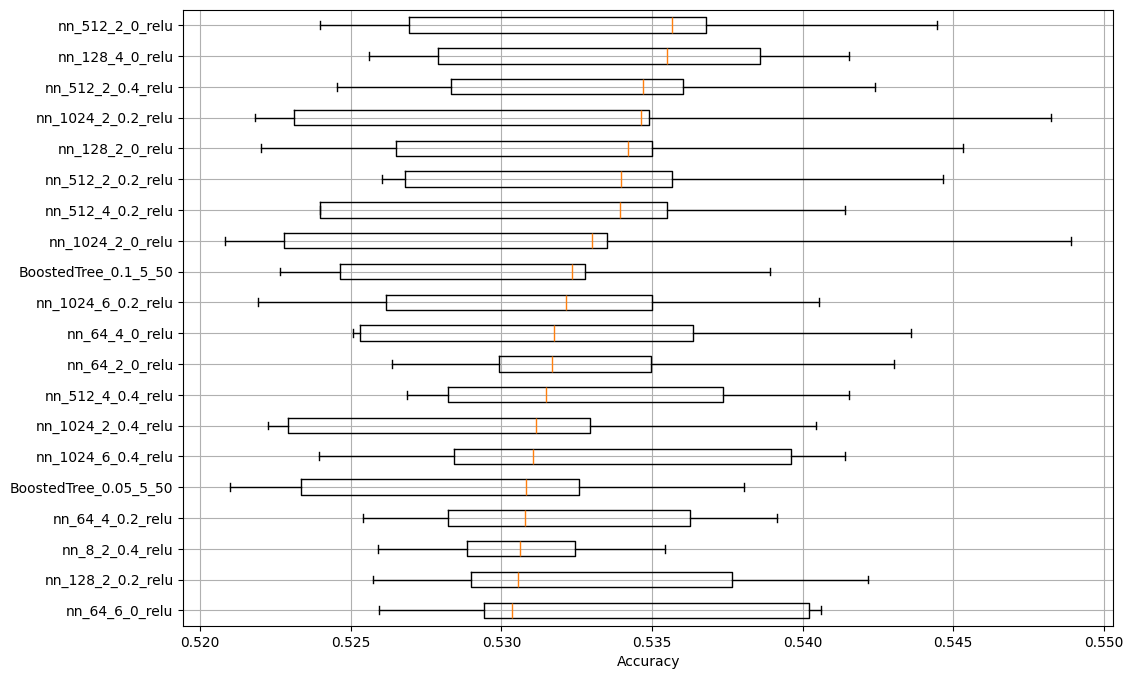

In [312]:
N_best = 20
scores_accuracy = np.vectorize(lambda x: x['accuracy'])(scores)
index_best = np.argsort(-np.median(scores_accuracy,axis=0))[:N_best]

fig, ax = plt.subplots(figsize=(12,8))
VP = ax.boxplot((scores_accuracy[:,index_best]), orientation='horizontal', tick_labels=labels[index_best], whis=10)

ax.invert_yaxis()

plt.xlabel("Accuracy")

plt.grid()

Although some models have very slightly better scores than others, the differences fall within the sampling variation and therefore, there is no clear winner.

In binary classification, an accuracy of around $0.5$ would be disastrous as it would be no better than random chance. Since we have $3$ target classes, random chance would yield $1/3$ accuracy, so an accuracy of around $0.52 - 0.54$ shows that the model learned some of the features. That being said, these models are still considered to be rather poor at classifing `Burnout_Risk_Level`.

On the folowing plot, I show the class `f1_score`, defined as the harmonic average of precision and recal, defined as
$$\text{F1}\equiv \frac{2}{1/\text{precision} + 1/\text{recall}},$$ and precision and recall is defined as
$$\text{precision} = \frac{\text{True Positives}}{\text{True Positives} + \text{False Positives}},$$
$$\text{recall} = \frac{\text{True Positives}}{\text{True Positives} + \text{False Negatives}}.$$

Basically, `precision` tell you if you can trust your model when he tells you some specific class. And recall tells you how many class elements where succesfully classified.

In the following plot, we plot the class `f1-score` of the top-10 accuracy performers.

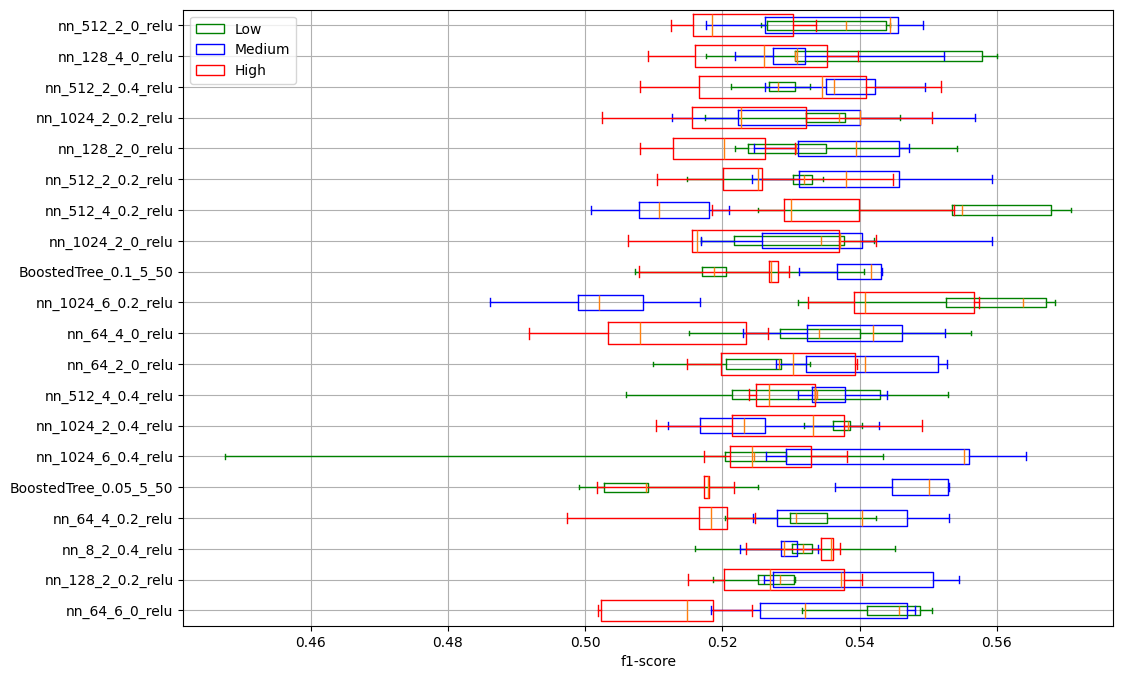

In [300]:
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(12,8))

score_labels = ["Low", "Medium", "High"]

colours_dic = dict(zip(score_labels, ["green", "blue", "red"]))

size_list = dict(zip(score_labels, [0.3,0.5,0.7]))

for score in score_labels:
    score_accuracy = np.vectorize(lambda x: x[score]['f1-score'])(scores)
    ax.boxplot((score_accuracy[:,index_best]), orientation='horizontal', whis=100, widths=size_list[score], capprops=dict(color=colours_dic[score]) ,whiskerprops=dict(color=colours_dic[score]), boxprops=dict(color=colours_dic[score]))

ax.invert_yaxis()

legend = [Patch(facecolor='white' ,edgecolor=colours_dic[score], label=score) for score in score_labels]

ax.legend(handles=legend, loc="upper left")

ax.set_yticks(range(1, len(labels[index_best]) + 1))
ax.set_yticklabels(labels[index_best])
ax.set_xlabel("f1-score")

ax.grid()
    
    

## Threshold tunning

In [364]:
from scipy.interpolate import CubicSpline

In [319]:
model = np.concat([np.array(models), np.array(nn_models)])[index_best[0]]

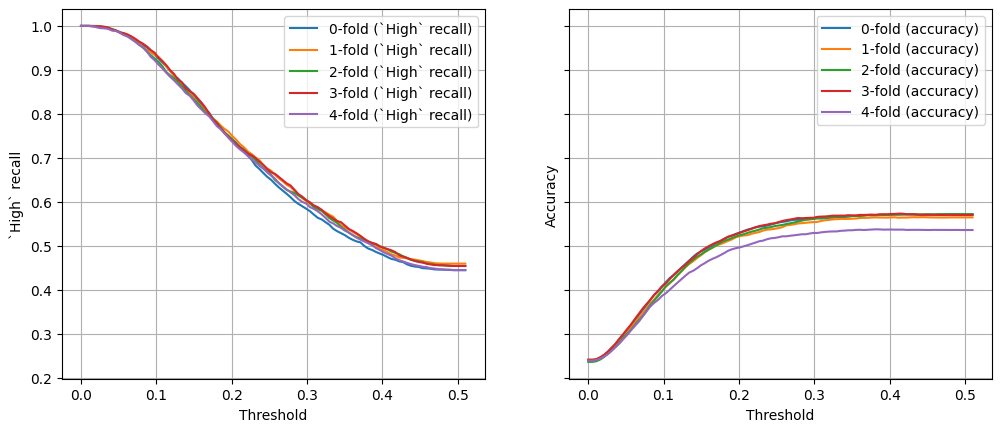

In [393]:
threshold_positions = []
accuracy_at_treshold = []

fig, ax = plt.subplots(1, 2, sharey=True, figsize=[12, 4.8])

for i, (train_index, test_index) in enumerate(kf.split(df[features])):
    X_train = df[features].iloc[train_index].to_numpy()
    y_train = df[target].iloc[train_index].to_numpy()

    X_test = df[features].iloc[test_index].to_numpy()
    y_test = df[target].iloc[test_index].to_numpy()
    
    scaler = StandardScaler()
    scaler.fit(X_train)

    X_train_scaled = scaler.transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    train_dataset = BurnoutDataset(X_train_scaled, y_train.flatten())
    test_dataset = BurnoutDataset(X_test_scaled, y_test.flatten())

    ## Train

    num_epochs=1000
    batch_size=1024
    train_dataloader = DataLoader(train_dataset, batch_size=batch_size)
    test_dataloader = DataLoader(test_dataset, batch_size=batch_size)
    
    X_test_tensor_scaled = torch.tensor(X_test_scaled, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test.flatten())
    
    model.eval()
        
    with torch.no_grad():
        pred = model(X_test_tensor_scaled)

    x_threshold = []
    y_recall = []
    y_accuracy = []
    
    for threshold in np.linspace(0,0.51,100):
        pred_treshold = np.array([2 if softmax_logit[2] > threshold else softmax_logit.argmax() for softmax_logit in torch.softmax(pred, dim=1).numpy()])
        report = classification_report(y_test.ravel(), pred_treshold, output_dict=True, zero_division=0)
        x_threshold.append(threshold)
        y_recall.append(report['2']['recall'])
        y_accuracy.append(report['accuracy'])
    
    ax[0].plot(x_threshold, y_recall, label=str(i) + "-fold (`High` recall)")
    ax[1].plot(x_threshold, y_accuracy, label=str(i) + "-fold (accuracy)")

    spline = CubicSpline(x_threshold, y_recall)
    optimal_treshold = spline.solve(0.9, extrapolate=False)
    threshold_positions.append(optimal_treshold)
    
    accuracy_at_treshold.append(CubicSpline(x_threshold, y_accuracy)(optimal_treshold))

ax[0].set_xlabel("Threshold")
ax[1].set_xlabel("Threshold")

ax[0].set_ylabel("`High` recall")
ax[1].set_ylabel("Accuracy")

ax[0].legend()
ax[0].grid()
ax[1].legend()
ax[1].grid()

plt.show()
            

In [379]:
print(np.array(threshold_positions).mean(), np.array(threshold_positions).std())
print(np.array(accuracy_at_treshold).mean(), np.array(accuracy_at_treshold).std())


0.11502472739132033 0.0034863235342496818
0.42720682641294394 0.014380786284689018


In [374]:
accuracy_at_treshold

[array([0.44020897]),
 array([0.43057458]),
 array([0.41977855]),
 array([0.44221013]),
 array([0.40326191])]